In [17]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

In [18]:
def find_project_root() -> Path:
    """Find the project directory containing the src folder."""
    current_directory = Path.cwd().resolve()

    for candidate in [
        current_directory,
        current_directory.parent,
    ]:
        if (candidate / "src").is_dir():
            return candidate

    raise RuntimeError(
        "Could not find the project root containing src/."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project root:", PROJECT_ROOT)

Project root: D:\astar-costmap-project


In [19]:
from src.cost_maps import build_safety_cost_maps
from src.evaluation import (
    evaluate_final_test,
    evaluate_learned_weight_sweep,
    evaluate_validation_baselines,
    summarize_planner_records,
)
from src.learned_cost import (
    build_learned_traversal_cost,
    predict_preference_map,
)
from src.metrics import (
    evaluate_path,
    symmetric_path_distance,
)
from src.models import LightweightUNet
from src.planners import (
    astar_search,
    cost_aware_astar,
    validate_path,
)
from src.scene_generator import generate_driving_scene
from src.visualization import plot_three_path_comparison

In [20]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = LightweightUNet(
    in_channels=5,
    out_channels=1,
    base_channels=16,
).to(device)

checkpoint = torch.load(
    PROJECT_ROOT
    / "models"
    / "best_unet.pt",
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Device:", device)

Loaded epoch: 30
Device: cuda


In [21]:
scene = generate_driving_scene(
    seed=20_000
)

In [22]:
standard_result = astar_search(
    free_space=scene.free_space,
    start=scene.start,
    goal=scene.goal,
)

In [23]:
expert_cost_maps = build_safety_cost_maps(
    scene
)

expert_result = cost_aware_astar(
    free_space=scene.free_space,
    traversal_cost=expert_cost_maps.traversal_cost,
    start=scene.start,
    goal=scene.goal,
)

In [24]:
preference_map = predict_preference_map(
    model=model,
    scene=scene,
    device=device,
)

learned_cost_maps = build_learned_traversal_cost(
    scene=scene,
    preference_map=preference_map,
    learned_weight=8.0,
)

cnn_result = cost_aware_astar(
    free_space=scene.free_space,
    traversal_cost=learned_cost_maps.traversal_cost,
    start=scene.start,
    goal=scene.goal,
)

In [25]:
print(
    "Standard success:",
    standard_result.success,
)

print(
    "Expert success:",
    expert_result.success,
)

print(
    "CNN-guided success:",
    cnn_result.success,
)

print(
    "CNN path valid:",
    validate_path(
        scene.free_space,
        cnn_result.path,
        scene.start,
        scene.goal,
    ),
)

Standard success: True
Expert success: True
CNN-guided success: True
CNN path valid: True


In [26]:
standard_metrics = evaluate_path(
    scene,
    standard_result.path,
)

expert_metrics = evaluate_path(
    scene,
    expert_result.path,
)

cnn_metrics = evaluate_path(
    scene,
    cnn_result.path,
)

print(
    f"{'Metric':<30}"
    f"{'Standard':>12}"
    f"{'Expert':>12}"
    f"{'CNN':>12}"
)

print("-" * 66)

metrics = [
    (
        "Path length",
        "path_length",
    ),
    (
        "Min obstacle clearance",
        "minimum_obstacle_clearance",
    ),
    (
        "Min boundary clearance",
        "minimum_boundary_clearance",
    ),
    (
        "Mean lane deviation",
        "mean_lane_deviation",
    ),
    (
        "Mean turn angle",
        "mean_turn_angle",
    ),
]

for label, attribute in metrics:
    print(
        f"{label:<30}"
        f"{getattr(standard_metrics, attribute):>12.3f}"
        f"{getattr(expert_metrics, attribute):>12.3f}"
        f"{getattr(cnn_metrics, attribute):>12.3f}"
    )

Metric                            Standard      Expert         CNN
------------------------------------------------------------------
Path length                         60.657      62.314      60.657
Min obstacle clearance               2.000       3.000       3.000
Min boundary clearance               7.000       8.000       8.000
Mean lane deviation                  1.083       0.706       0.907
Mean turn angle                      0.041       0.203       0.108


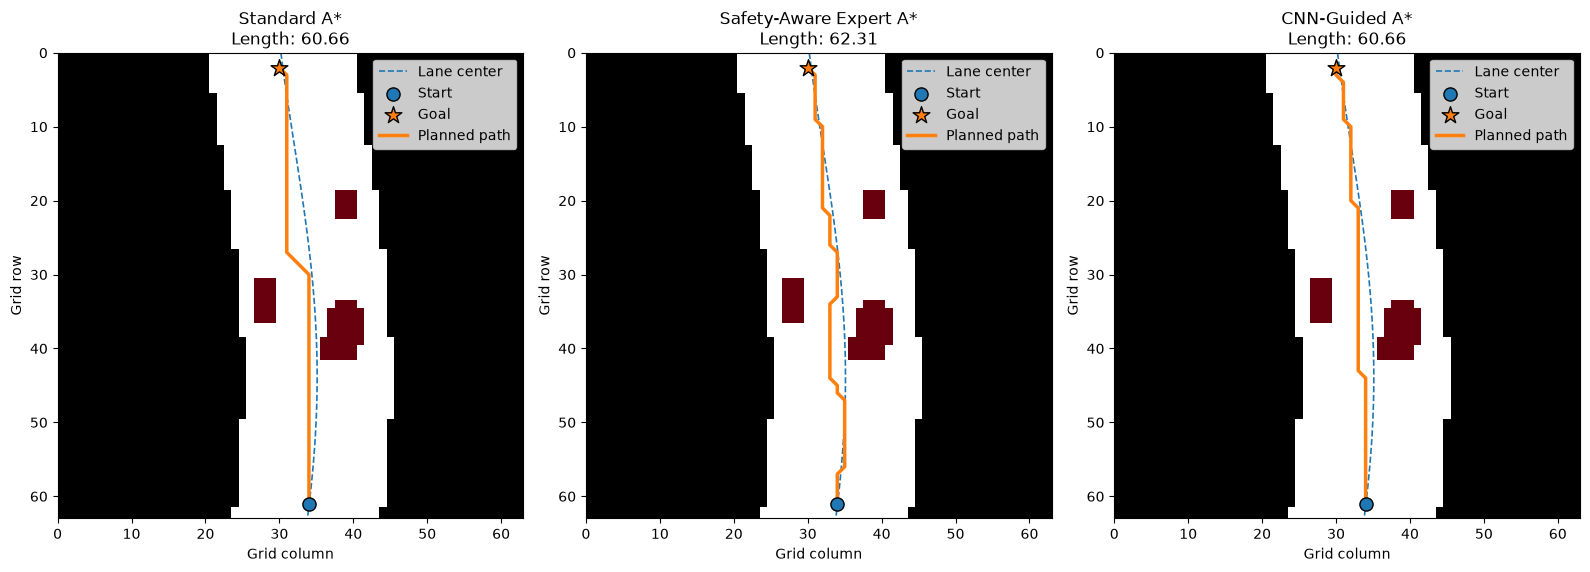

In [27]:
plot_three_path_comparison(
    scene=scene,
    standard_result=standard_result,
    expert_result=expert_result,
    cnn_result=cnn_result,
)

In [28]:
validation_seeds = range(
    10_000,
    10_100,
)

candidate_weights = [
    2.0,
    4.0,
    8.0,
    12.0,
]

weight_results = evaluate_learned_weight_sweep(
    model=model,
    device=device,
    seeds=validation_seeds,
    learned_weights=candidate_weights,
)

Evaluated 20/100 scenes.
Evaluated 40/100 scenes.
Evaluated 60/100 scenes.
Evaluated 80/100 scenes.
Evaluated 100/100 scenes.


In [29]:
weight_summaries = {
    weight: summarize_planner_records(
        records
    )
    for weight, records
    in weight_results.items()
}

print(
    f"{'Weight':>8}"
    f"{'Success':>10}"
    f"{'Length':>12}"
    f"{'Obs Clear':>12}"
    f"{'Boundary':>12}"
    f"{'Lane Dev':>12}"
    f"{'Turn':>10}"
)

print("-" * 76)

for weight in candidate_weights:
    summary = weight_summaries[
        weight
    ]

    print(
        f"{weight:>8.1f}"
        f"{summary['success_rate']:>10.3f}"
        f"{summary['path_length']:>12.3f}"
        f"{summary['minimum_obstacle_clearance']:>12.3f}"
        f"{summary['minimum_boundary_clearance']:>12.3f}"
        f"{summary['mean_lane_deviation']:>12.3f}"
        f"{summary['mean_turn_angle']:>10.3f}"
    )

  Weight   Success      Length   Obs Clear    Boundary    Lane Dev      Turn
----------------------------------------------------------------------------
     2.0     1.000      62.315       2.122       7.304       1.030     0.155
     4.0     1.000      62.485       2.181       7.240       1.047     0.165
     8.0     1.000      62.621       2.208       7.201       1.054     0.172
    12.0     1.000      62.679       2.218       7.197       1.054     0.176


In [30]:
standard_records, expert_records = (
    evaluate_validation_baselines(
        validation_seeds
    )
)

standard_summary = summarize_planner_records(
    standard_records
)

expert_summary = summarize_planner_records(
    expert_records
)

Evaluated 20/100 scenes.
Evaluated 40/100 scenes.
Evaluated 60/100 scenes.
Evaluated 80/100 scenes.
Evaluated 100/100 scenes.


In [31]:
print(
    f"{'Method':<15}"
    f"{'Success':>10}"
    f"{'Length':>12}"
    f"{'Obs Clear':>12}"
    f"{'Boundary':>12}"
    f"{'Lane Dev':>12}"
    f"{'Turn':>10}"
)

print("-" * 83)

methods = [
    ("Standard", standard_summary),
    ("Expert", expert_summary),
]

for weight in candidate_weights:
    methods.append(
        (
            f"CNN λ={weight:g}",
            weight_summaries[weight],
        )
    )

for method_name, summary in methods:
    print(
        f"{method_name:<15}"
        f"{summary['success_rate']:>10.3f}"
        f"{summary['path_length']:>12.3f}"
        f"{summary['minimum_obstacle_clearance']:>12.3f}"
        f"{summary['minimum_boundary_clearance']:>12.3f}"
        f"{summary['mean_lane_deviation']:>12.3f}"
        f"{summary['mean_turn_angle']:>10.3f}"
    )

Method            Success      Length   Obs Clear    Boundary    Lane Dev      Turn
-----------------------------------------------------------------------------------
Standard            1.000      60.934       1.327       7.048       1.579     0.061
Expert              1.000      62.749       2.496       7.036       1.119     0.139
CNN λ=2             1.000      62.315       2.122       7.304       1.030     0.155
CNN λ=4             1.000      62.485       2.181       7.240       1.047     0.165
CNN λ=8             1.000      62.621       2.208       7.201       1.054     0.172
CNN λ=12            1.000      62.679       2.218       7.197       1.054     0.176


In [32]:
standard_to_expert_distance = (
    symmetric_path_distance(
        standard_result.path,
        expert_result.path,
    )
)

cnn_to_expert_distance = (
    symmetric_path_distance(
        cnn_result.path,
        expert_result.path,
    )
)

print(
    "Standard-to-Expert distance:",
    f"{standard_to_expert_distance:.3f}",
)

print(
    "CNN-to-Expert distance:",
    f"{cnn_to_expert_distance:.3f}",
)

Standard-to-Expert distance: 0.794
CNN-to-Expert distance: 0.333


In [33]:
final_test_seeds = range(
    30_000,
    30_100,
)

final_results = evaluate_final_test(
    model=model,
    device=device,
    seeds=final_test_seeds,
    learned_weight=2.0,
)

Final test: 20/100 scenes.
Final test: 40/100 scenes.
Final test: 60/100 scenes.
Final test: 80/100 scenes.
Final test: 100/100 scenes.


In [ ]:
final_standard_summary = summarize_planner_records(
    final_results["standard"]
)

final_expert_summary = summarize_planner_records(
    final_results["expert"]
)

final_cnn_summary = summarize_planner_records(
    final_results["cnn"]
)

print("Final held-out evaluation over 100 scenes")
print("=" * 105)

print(
    f"{'Method':<15}"
    f"{'Success':>10}"
    f"{'Length':>12}"
    f"{'Obs Clear':>12}"
    f"{'Boundary':>12}"
    f"{'Lane Dev':>12}"
    f"{'Turn':>10}"
    f"{'Expert Dist':>14}"
)

print("-" * 105)

final_methods = [
    ("Standard", final_standard_summary),
    ("Expert", final_expert_summary),
    ("CNN-guided", final_cnn_summary),
]

for method_name, summary in final_methods:
    print(
        f"{method_name:<15}"
        f"{summary['success_rate']:>10.3f}"
        f"{summary['path_length']:>12.3f}"
        f"{summary['minimum_obstacle_clearance']:>12.3f}"
        f"{summary['minimum_boundary_clearance']:>12.3f}"
        f"{summary['mean_lane_deviation']:>12.3f}"
        f"{summary['mean_turn_angle']:>10.3f}"
        f"{summary['distance_to_expert']:>14.3f}"
    )